Homework 1: Garrett White

In [2]:
from google.colab import files

uploaded = files.upload()

Saving UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1 (1).zip to UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1 (1).zip


In [3]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/hw")

print("Extracted to /content/hw")

Extracted to /content/hw


In [5]:
import os
os.chdir("/content/hw")

print("Current directory:", os.getcwd())

Current directory: /content/hw


In [7]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "bond_symbology.xlsx":
            print(os.path.join(root, file))

/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_symbology.xlsx


In [9]:
import pandas as pd

bond_sym = pd.read_excel("/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_symbology.xlsx")

bond_sym.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,...,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,...,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,...,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,...,2015-05-13,2015-11-13,2015-05-13,2045-05-13,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,...,2016-02-23,2016-08-23,2016-02-23,2036-02-23,CALLABLE,Sr Unsecured,1250.0,US,USD,ACTV


------------------------------------------------------------------------------------------
# Problem 1: Explore symbology for US treasury bonds

## a. Load and explore US government bond symbology

Load the `bond_symbology` Excel file into a dataframe. It contains symbology for both government and corporate bonds as of 2026-03-23.

Select US Treasury bonds only (class = 'Govt', ticker = 'T'). For each government bond issue, calculate its initial `term` in years (based on issue date and maturity date), as well as the current `TTM` (time-to-maturity) and extend the dataframe. Assume a year has 365.25 days.


In [11]:
bond_sym = pd.read_excel(
    "/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_symbology.xlsx"
)

govt = bond_sym[(bond_sym["class"] == "Govt") & (bond_sym["ticker"] == "T")].copy()

govt["start_date"] = pd.to_datetime(govt["start_date"])
govt["maturity"] = pd.to_datetime(govt["maturity"])

today = pd.to_datetime("2026-03-23")

govt["term"] = (govt["maturity"] - govt["start_date"]).dt.days / 365.25
govt["TTM"] = (govt["maturity"] - today).dt.days / 365.25

govt.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,term,TTM
893,T,Govt,BBG000DKHP42,US912810EG95,US9127963M90,T 8 3/4 08/15/20,US TREASURY N/B,US GOVERNMENT,8.750,FIXED,...,1990-08-15,2020-08-15,NORMAL,Unsecured,17059.0,US,USD,INAC,30.001369,-5.601643
894,T,Govt,BBG000DJN4B7,US912810EH78,NaN,T 7 7/8 02/15/21,US TREASURY N/B,US GOVERNMENT,7.875,FIXED,...,1991-02-15,2021-02-15,NORMAL,Unsecured,10076.0,US,USD,INAC,30.001369,-5.097878
895,T,Govt,BBG000DHBM88,US912810EJ35,NaN,T 8 1/8 05/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-05-15,2021-05-15,NORMAL,Unsecured,10067.0,US,USD,INAC,30.001369,-4.854209
896,T,Govt,BBG000DKP182,US912810EK08,NaN,T 8 1/8 08/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-08-15,2021-08-15,NORMAL,Unsecured,9506.0,US,USD,INAC,30.001369,-4.602327
897,T,Govt,BBG000DFRYP0,US912810EL80,NaN,T 8 11/15/21,US TREASURY N/B,US GOVERNMENT,8.000,FIXED,...,1991-11-15,2021-11-15,NORMAL,Unsecured,30632.0,US,USD,INAC,30.001369,-4.350445


## b. Historical time series of US treasury coupons

Plot the time series of coupons for for US treasury notes/bonds issued since 2019 (indexed by issue date).
What can you say about the overall level of issued coupons since 2024?


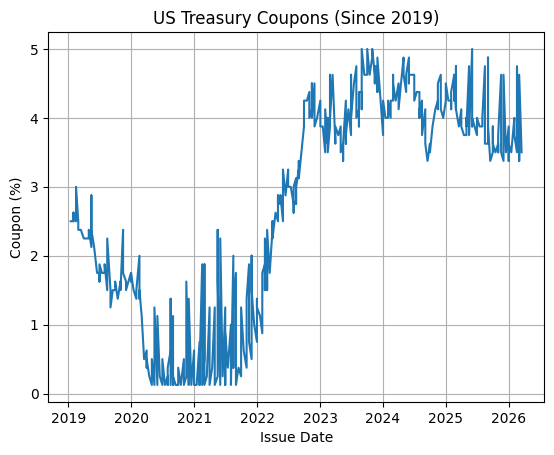

In [12]:
import matplotlib.pyplot as plt

recent = govt[govt["start_date"] >= "2019-01-01"].copy()
recent = recent.sort_values("start_date")

plt.figure()
plt.plot(recent["start_date"], recent["coupon"])
plt.title("US Treasury Coupons (Since 2019)")
plt.xlabel("Issue Date")
plt.ylabel("Coupon (%)")
plt.grid()
plt.show()

The time series shows a clear upward shift in coupon levels for bonds issued in recent years, with most new issues clustering at higher coupon rates compared to pre-2022 issuance. This indicates that the cost of borrowing for the U.S. government has increased alongside the broader rise in interest rates. The coupon rates in since 2024 have clearly been at elevated levels.

## c. Load the on-the-run US treasuries

Load the `govt_on_the_run` Excel file into a dataframe. Select the current on-the-run 2Y, 3Y, 5Y, 7Y, 10Y, 20Y and 30Y issues (off-the-run issues have the B & C suffix). Create a separate symbology dataframe for on-the-run treasuries only, to be used later on for the on-the-run government yield curve bootstrapping.

In [19]:
otrun = pd.read_excel(
    "/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/govt_on_the_run.xlsx"
)

otrun = otrun[~otrun["ticker"].str.contains("B|C", na=False)].copy()

otrun["tenor"] = otrun["ticker"].str.extract(r"GT(\d+)").astype(float)

otrun["tenor"] = otrun["tenor"].astype(int).astype(str) + "Y"

keep = ["2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
otrun = otrun[otrun["tenor"].isin(keep)].copy()

otrun

,ticker,date,figi,isin,tenor
0,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85,10Y
3,GT2 Govt,2026-03-23,BBG020BMV715,US91282CQB09,2Y
4,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33,20Y
9,GT3 Govt,2026-03-23,BBG020PVMGR2,US91282CQE48,3Y
10,GT30 Govt,2026-03-23,BBG01ZZ4GDS8,US912810UR76,30Y
15,GT5 Govt,2026-03-23,BBG020BMV760,US91282CQD64,5Y
18,GT7 Govt,2026-03-23,BBG020BMV6Z0,US91282CQC81,7Y


## d. Compute the total amount of US Treasuries issued / matured every year since 2019

Column `amt_out` contains the issue amount outstanding, expressed in $MM.

Compute the total amount of US Treasuries issued every year since 2019.
Compute the total amount of US Treasuries matured every year since 2019.

Plot the results.

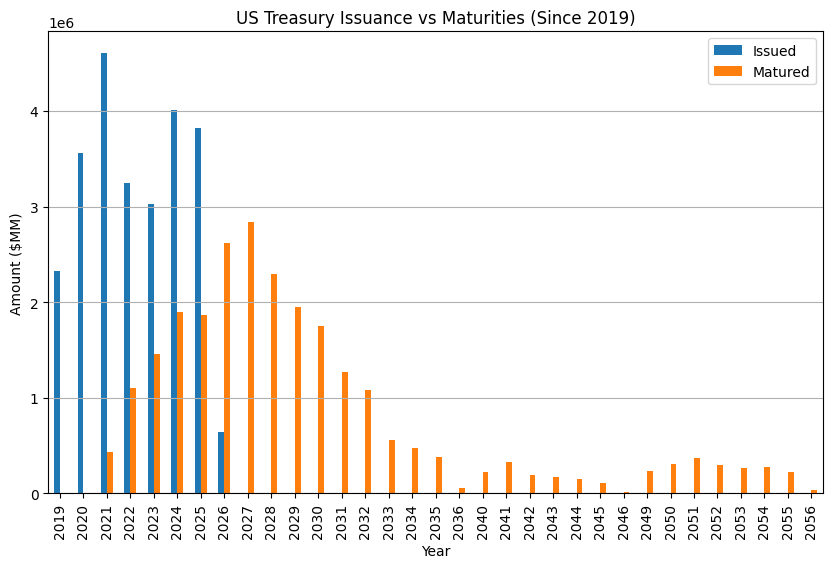

Total Issued by Year:
issue_year
2019    2322466.0
2020    3558513.0
2021    4601404.0
2022    3251806.0
2023    3028042.0
2024    4012135.0
2025    3817659.0
2026     638191.0
Name: amt_out, dtype: float64

Total Matured by Year:
maturity_year
2021     430462.0
2022    1104566.0
2023    1457480.0
2024    1900963.0
2025    1869432.0
2026    2623432.0
2027    2837253.0
2028    2299402.0
2029    1945587.0
2030    1753457.0
2031    1266219.0
2032    1078999.0
2033     556431.0
2034     476991.0
2035     383640.0
2036      53901.0
2040     221629.0
2041     325438.0
2042     189194.0
2043     171042.0
2044     147682.0
2045     113108.0
2046      17917.0
2049     236479.0
2050     308693.0
2051     366237.0
2052     297702.0
2053     266595.0
2054     275118.0
2055     223083.0
2056      32084.0
Name: amt_out, dtype: float64


In [21]:
bond_sym = pd.read_excel(
    "/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_symbology.xlsx"
)

govt = bond_sym[(bond_sym["class"] == "Govt") & (bond_sym["ticker"] == "T")].copy()

govt["start_date"] = pd.to_datetime(govt["start_date"])
govt["maturity"] = pd.to_datetime(govt["maturity"])

govt["issue_year"] = govt["start_date"].dt.year
govt["maturity_year"] = govt["maturity"].dt.year

govt = govt[govt["issue_year"] >= 2019].copy()

govt["amt_out"] = pd.to_numeric(govt["amt_out"], errors="coerce")

issued = govt.groupby("issue_year")["amt_out"].sum()

matured = govt.groupby("maturity_year")["amt_out"].sum()

yearly = pd.DataFrame({
    "Issued": issued,
    "Matured": matured
}).fillna(0)

# Plot
yearly.plot(kind="bar", figsize=(10, 6))
plt.title("US Treasury Issuance vs Maturities (Since 2019)")
plt.xlabel("Year")
plt.ylabel("Amount ($MM)")
plt.legend()
plt.grid(axis="y")

plt.show()

print("Total Issued by Year:")
print(issued)

print("\nTotal Matured by Year:")
print(matured)

------------------------------------------------------------------------------------------
# Problem 2: Explore symbology for corporate bonds

## a. Load and explore US corporate bonds symbology data

Starting from the `bond_symbology` dataframe, create a corporate bond dataframe containing
* corporate bond only  (class = "Corp"),
* senior unsecured (rank = "Sr Unsecured"),
* fixed coupon (cpn_type="FIXED")
* maturity date <= 2055-12-31

bonds only, with following columns:



| ticker | isin | figi | security | name | coupon | start_date | maturity | amt_out | term | TTM |
|----------|-------|-------|-------------|-----|----------|---------|---------|---------|---------|---------|

where
* `term` refers to the initial term/time-to-maturity in years
* `TTM` refers to the current time-to-maturity in years

Display the dataframe.

In [22]:
bond_sym = pd.read_excel(
    "/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_symbology.xlsx"
)

corp = bond_sym[
    (bond_sym["class"] == "Corp") &
    (bond_sym["rank"] == "Sr Unsecured") &
    (bond_sym["cpn_type"] == "FIXED")
].copy()

corp["maturity"] = pd.to_datetime(corp["maturity"])
corp = corp[corp["maturity"] <= "2055-12-31"].copy()

corp["start_date"] = pd.to_datetime(corp["start_date"])

today = pd.Timestamp("2026-03-23")

corp["term"] = (corp["maturity"] - corp["start_date"]).dt.days / 365.25
corp["TTM"] = (corp["maturity"] - today).dt.days / 365.25

corp = corp[[
    "ticker", "isin", "figi", "security", "name",
    "coupon", "start_date", "maturity", "amt_out",
    "term", "TTM"
]]

corp

,ticker,isin,figi,security,name,coupon,start_date,maturity,amt_out,term,TTM
0,AAPL,US037833AL42,BBG004HST0K7,AAPL 3.85 05/04/43,APPLE INC,3.850,2013-05-03,2043-05-04,3000.000,30.001369,17.114305
1,AAPL,US037833AT77,BBG006F8VWJ7,AAPL 4.45 05/06/44,APPLE INC,4.450,2014-05-06,2044-05-06,1000.000,30.001369,18.121834
2,AAPL,US037833BA77,BBG0081TNL50,AAPL 3.45 02/09/45,APPLE INC,3.450,2015-02-09,2045-02-09,2000.000,30.001369,18.885695
3,AAPL,US037833BH21,BBG008N1BQC1,AAPL 4 3/8 05/13/45,APPLE INC,4.375,2015-05-13,2045-05-13,2000.000,30.001369,19.140315
4,AAPL,US037833BW97,BBG00C7QBCQ1,AAPL 4 1/2 02/23/36,APPLE INC,4.500,2016-02-23,2036-02-23,1250.000,20.000000,9.921971
...,...,...,...,...,...,...,...,...,...,...,...
1736,VZ,US92346MNY39,BBG01PSW38L8,VZ 5.1 09/15/54,VERIZON COMMUNICATIONS,5.100,2024-09-26,2054-09-15,3.279,29.968515,28.481862
1737,VZ,US92346MNZ04,BBG01PZXTGX9,VZ 4.05 10/15/29,VERIZON COMMUNICATIONS,4.050,2024-10-03,2029-10-15,0.000,5.032170,3.564682
1738,VZ,US92346MPA35,BBG01PZXTKV2,VZ 5.05 10/15/54,VERIZON COMMUNICATIONS,5.050,2024-10-03,2054-10-15,0.000,30.031485,28.563997
1739,VZ,USU9221ABY39,BBG012MB8P10,VZ 2.355 03/15/32,VERIZON COMMUNICATIONS,2.355,2021-09-20,2032-03-15,37.830,10.483231,5.979466


## b. Explore aggregated issue amount outstanding by issuer

Compute the total issue (face) amount outstanding for each issuer and display the results.

In [23]:
issuer_amt = corp.groupby("ticker")["amt_out"].sum().sort_values(ascending=False)

issuer_amt

,amt_out
ticker,
ORCL,102490.435000
VZ,88745.606188
AAPL,65100.000000
META,48614.249000
GM,37703.712000
F,35561.931000
MSFT,31642.036000
IBM,30334.172000
DIS,26625.751000


## c. Display the bond details for APPLE INC (ticker AAPL)

Create a separate dataframe for Apple issuer only (ticker = 'AAPL') and display it.

Compute following aggregated metrics for AAPL:
* average coupon
* average term and
* average TTM.

In [24]:
aapl = corp[corp["ticker"] == "AAPL"].copy()

display(aapl)

avg_coupon = aapl["coupon"].mean()
avg_term = aapl["term"].mean()
avg_ttm = aapl["TTM"].mean()

print("AAPL Average Coupon:", avg_coupon)
print("AAPL Average Term:", avg_term)
print("AAPL Average TTM:", avg_ttm)

,ticker,isin,figi,security,name,coupon,start_date,maturity,amt_out,term,TTM
0,AAPL,US037833AL42,BBG004HST0K7,AAPL 3.85 05/04/43,APPLE INC,3.850,2013-05-03,2043-05-04,3000.0,30.001369,17.114305
1,AAPL,US037833AT77,BBG006F8VWJ7,AAPL 4.45 05/06/44,APPLE INC,4.450,2014-05-06,2044-05-06,1000.0,30.001369,18.121834
2,AAPL,US037833BA77,BBG0081TNL50,AAPL 3.45 02/09/45,APPLE INC,3.450,2015-02-09,2045-02-09,2000.0,30.001369,18.885695
3,AAPL,US037833BH21,BBG008N1BQC1,AAPL 4 3/8 05/13/45,APPLE INC,4.375,2015-05-13,2045-05-13,2000.0,30.001369,19.140315
4,AAPL,US037833BW97,BBG00C7QBCQ1,AAPL 4 1/2 02/23/36,APPLE INC,4.500,2016-02-23,2036-02-23,1250.0,20.000000,9.921971
5,AAPL,US037833BX70,BBG00C7QBG91,AAPL 4.65 02/23/46,APPLE INC,4.650,2016-02-23,2046-02-23,4000.0,30.001369,19.923340
6,AAPL,US037833CD08,BBG00DHQX9M5,AAPL 3.85 08/04/46,APPLE INC,3.850,2016-08-04,2046-08-04,2000.0,29.998631,20.366872
7,AAPL,US037833CH12,BBG00FXTSMV3,AAPL 4 1/4 02/09/47,APPLE INC,4.250,2017-02-09,2047-02-09,1000.0,29.998631,20.884326
8,AAPL,US037833CJ77,BBG00FXTS8Z0,AAPL 3.35 02/09/27,APPLE INC,3.350,2017-02-09,2027-02-09,2250.0,9.998631,0.884326
9,AAPL,US037833CR93,BBG00GNBL206,AAPL 3.2 05/11/27,APPLE INC,3.200,2017-05-11,2027-05-11,2000.0,9.998631,1.133470


AAPL Average Coupon: 3.2923076923076904
AAPL Average Term: 17.89726039418031
AAPL Average TTM: 11.685498165990978


## d. Explore term structure of issue amounts outstanding for Apple.

Plot the issue amount outstanding by TTM for Apple.

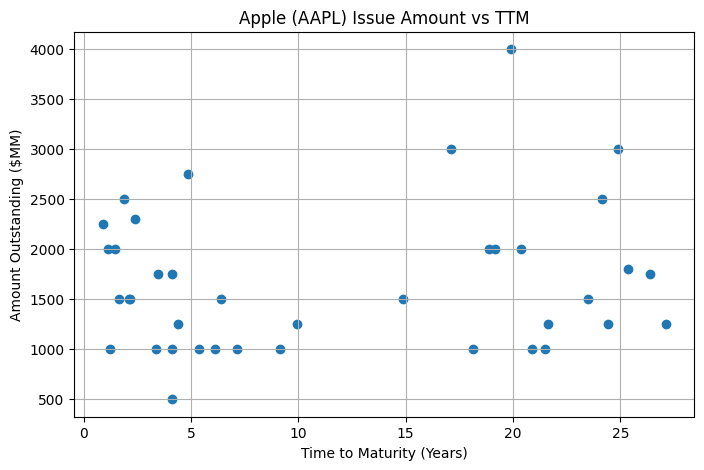

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(aapl["TTM"], aapl["amt_out"])

plt.title("Apple (AAPL) Issue Amount vs TTM")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Amount Outstanding ($MM)")

plt.grid(True)
plt.show()

------------------------------------------------------------------------------------------
# Problem 3: Explore EOD market prices and yields

## a. Load and explore treasury market prices and yields

Load the `bond_market_prices_eod` Excel file into a dataframe. It provides market data for US treasuries and corporate bonds as of 2026-03-23.

Merge the treasuries symbology dataframe with the market data and add the following columns:


| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

Plot a graph/scatter plot of treasury mid yields by TTM.


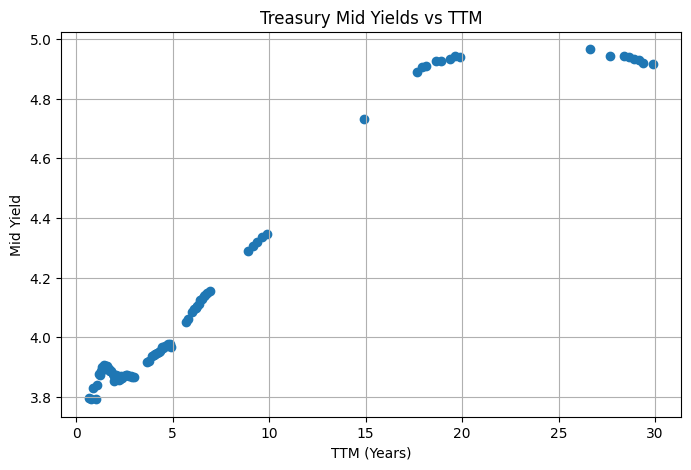

In [28]:
prices = pd.read_excel(
    "/content/hw/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_1/data/bond_market_prices_eod.xlsx"
)

prices["midPrice"] = (prices["bidPrice"] + prices["askPrice"]) / 2
prices["midYield"] = (prices["bidYield"] + prices["askYield"]) / 2

treasury = bond_sym[(bond_sym["class"] == "Govt") & (bond_sym["ticker"] == "T")].copy()

treasury_mkt = treasury.merge(prices, on="figi", how="inner")

treasury_mkt["maturity"] = pd.to_datetime(treasury_mkt["maturity"])
today = pd.Timestamp("2026-03-23")

treasury_mkt["TTM"] = (treasury_mkt["maturity"] - today).dt.days / 365.25

plt.figure(figsize=(8,5))
plt.scatter(treasury_mkt["TTM"], treasury_mkt["midYield"])

plt.title("Treasury Mid Yields vs TTM")
plt.xlabel("TTM (Years)")
plt.ylabel("Mid Yield")

plt.grid(True)
plt.show()

## b. Explore on-the-run treasuries only
Create a separate joint dataframe for on-the-run treasuries only.

Plot a graph/scatter plot of on-the-run treasury mid yields by TTM.

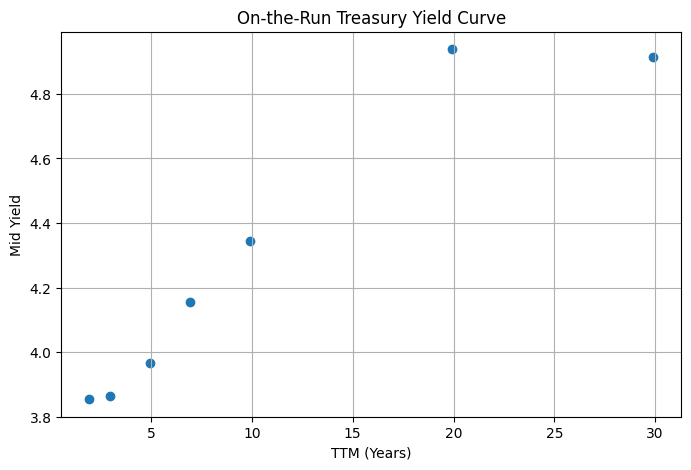

In [30]:
ot_full = otrun.merge(
    bond_sym[["figi", "maturity"]],
    on="figi",
    how="left"
)

ot_mkt = ot_full.merge(prices, on="figi", how="inner")

ot_mkt["maturity"] = pd.to_datetime(ot_mkt["maturity"])

today = pd.Timestamp("2026-03-23")
ot_mkt["TTM"] = (ot_mkt["maturity"] - today).dt.days / 365.25

ot_mkt["midYield"] = (ot_mkt["bidYield"] + ot_mkt["askYield"]) / 2

plt.figure(figsize=(8,5))
plt.scatter(ot_mkt["TTM"], ot_mkt["midYield"])

plt.title("On-the-Run Treasury Yield Curve")
plt.xlabel("TTM (Years)")
plt.ylabel("Mid Yield")

plt.grid(True)
plt.show()

## c. Load and explore corporate bond market prices and yields

Merge the filtered corporate bonds symbology dataframe with the market data and add the following columns:

| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

List the unique tickers/issuers available in the dataframe.


In [36]:
corp_mkt = corp_sym.merge(prices, on="figi", how="inner")

corp_mkt["midPrice"] = (corp_mkt["bidPrice"] + corp_mkt["askPrice"]) / 2
corp_mkt["midYield"] = (corp_mkt["bidYield"] + corp_mkt["askYield"]) / 2

corp_mkt["maturity"] = pd.to_datetime(corp_mkt["maturity"])
corp_mkt["start_date"] = pd.to_datetime(corp_mkt["start_date"])
today = pd.Timestamp("2026-03-23")

corp_mkt["TTM"] = (corp_mkt["maturity"] - today).dt.days / 365.25

corp_mkt["term"] = (corp_mkt["maturity"] - corp_mkt["start_date"]).dt.days / 365.25

corp_mkt = corp_mkt[
    ["date", "bidPrice", "askPrice", "midPrice",
     "bidYield", "askYield", "midYield", "term", "TTM", "ticker_x"]
]

print(corp_mkt["ticker_x"].unique())

corp_mkt.head()

['AAPL' 'DIS' 'F' 'GM' 'IBM' 'JPM' 'META' 'MS' 'MSFT' 'NVDA' 'ORCL' 'VZ']


,date,bidPrice,askPrice,midPrice,bidYield,askYield,midYield,term,TTM,ticker_x
0,2026-03-23,82.414444,82.414444,82.414444,5.442,5.442,5.442,30.001369,17.114305,AAPL
1,2026-03-23,89.116091,89.116091,89.116091,5.399,5.399,5.399,30.001369,18.121834,AAPL
2,2026-03-23,75.855577,75.855577,75.855577,5.526,5.526,5.526,30.001369,18.885695,AAPL
3,2026-03-23,86.818216,86.818216,86.818216,5.497,5.497,5.497,30.001369,19.140315,AAPL
4,2026-03-23,99.575093,99.575093,99.575093,4.553,4.553,4.553,20.000000,9.921971,AAPL


## d. Yield curve plots

Plot a graph/scatter plot of mid yield curves by TTM (one line per ticker/issuer).

Add a separate line for on-the-run US treasury yield curve (risk free curve).

What can you say about the credit issuer yields, compared to US treasury yields?

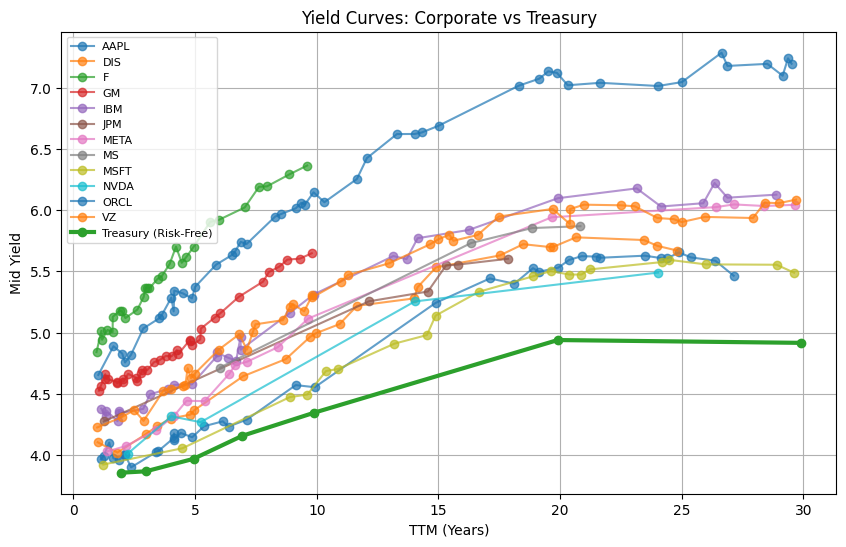

In [37]:
corp_mkt = corp_mkt.rename(columns={"ticker_x": "ticker"})

treasury_curve = ot_mkt[["TTM", "midYield"]].copy()
treasury_curve = treasury_curve.sort_values("TTM")

plt.figure(figsize=(10,6))

for tkr in corp_mkt["ticker"].unique():
    df = corp_mkt[corp_mkt["ticker"] == tkr].sort_values("TTM")
    plt.plot(df["TTM"], df["midYield"], marker='o', alpha=0.7, label=tkr)

plt.plot(
    treasury_curve["TTM"],
    treasury_curve["midYield"],
    marker='o',
    linewidth=3,
    label="Treasury (Risk-Free)"
)

plt.xlabel("TTM (Years)")
plt.ylabel("Mid Yield")
plt.title("Yield Curves: Corporate vs Treasury")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

Credit issuer yields are consistently higher than US Treasury yields across maturities, reflecting the additional compensation investors require for bearing credit risk. While Treasury securities are considered risk-free in terms of default risk, corporate bonds incorporate the possibility of default, as well as liquidity and issuer-specific risks, which leads to a positive credit spread over Treasuries. This spread varies across issuers and tends to be larger for lower-rated firms and longer maturities, where uncertainty is greater. As a result, corporate yield curves generally lie above the Treasury curve and can differ in shape across issuers, while the Treasury curve serves as a smooth benchmark for the risk-free term structure

------------------------------------------------------------------------------------------
# Problem 4: Underying treasury benchmarks and credit spreads

## a. Add underlying benchmark bond mid yields

Start with the corporate bond symbology dataframe and filter following tickers only: AAPL, IBM, MSFT, ORCL and VZ. Use the column 'und_bench_yield' to identify the underlying benchmark bond for each bond issue.

Add two new columns to the joint corporate bond dataframe:

| und_bench_yield | credit_spread |
|----------|-------|

where

*  `und_bench_yield` = underlying benchmark bond mid yield and
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

In [51]:
import numpy as np

tickers_keep = ["AAPL", "IBM", "MSFT", "ORCL", "VZ"]
corp_4a = corp_sym[corp_sym["ticker"].isin(tickers_keep)].copy()

corp_4a = corp_4a.merge(prices, on="figi", how="inner")

corp_4a["midYield"] = (corp_4a["bidYield"] + corp_4a["askYield"]) / 2

corp_4a["maturity"] = pd.to_datetime(corp_4a["maturity"])
today = pd.Timestamp("2026-03-23")
corp_4a["TTM"] = (corp_4a["maturity"] - today).dt.days / 365.25

corp_4a["und_bench_yield"] = np.interp(
    corp_4a["TTM"],
    treasury_curve["TTM"],
    treasury_curve["midYield"]
)

corp_4a["credit_spread"] = (corp_4a["midYield"] - corp_4a["und_bench_yield"]) * 100

corp_4a = corp_4a.rename(columns={
    "ticker_x": "ticker",
    "isin_x": "isin"
})

corp_4a[[
    "ticker", "isin", "und_bench_yield",
    "credit_spread", "TTM"
]].head()

,ticker,isin,und_bench_yield,credit_spread,TTM
0,AAPL,US037833AL42,4.773106,66.889365,17.114305
1,AAPL,US037833AT77,4.832895,56.610498,18.121834
2,AAPL,US037833BA77,4.878224,64.777607,18.885695
3,AAPL,US037833BH21,4.893334,60.366644,19.140315
4,AAPL,US037833BW97,4.346300,20.670025,9.921971


## b. Credit spread curve plots

Plot a graph/scatter plot of credit spread curves by TTM (one line per issuer).


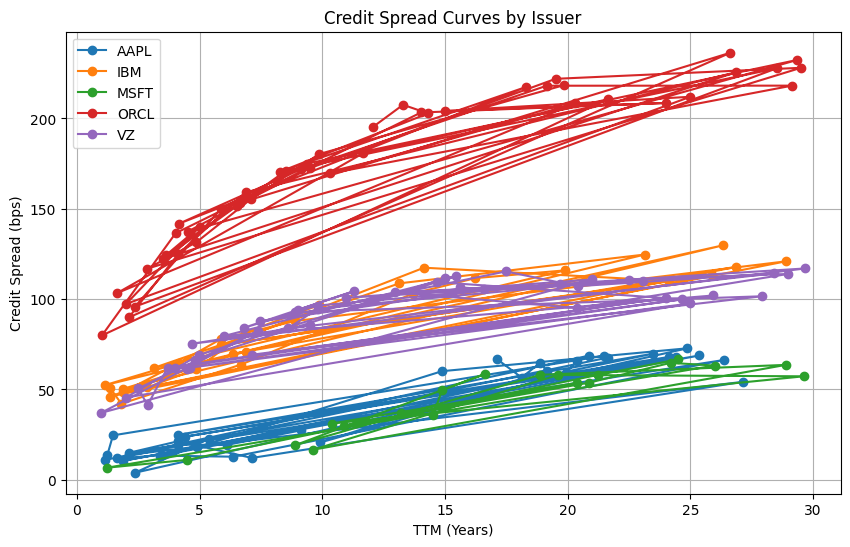

In [52]:
plt.figure(figsize=(10, 6))

for ticker in ["AAPL", "IBM", "MSFT", "ORCL", "VZ"]:
    subset = corp_4a[corp_4a["ticker"] == ticker]

    plt.plot(
        subset["TTM"],
        subset["credit_spread"],
        marker="o",
        label=ticker
    )

plt.xlabel("TTM (Years)")
plt.ylabel("Credit Spread (bps)")
plt.title("Credit Spread Curves by Issuer")
plt.legend()
plt.grid(True)

plt.show()

## c. Add g-spreads

Add two new columns to the joint corporate bond dataframe:

| interp_tsy_yield | g_spread |
|----------|-------|

where

*  `interp_tsy_yield` = interpolated treasury yield (using on-the-run treasuries only), matching the issue maturity
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

In [53]:
corp_4a["interp_tsy_yield"] = np.interp(
    corp_4a["TTM"],
    treasury_curve["TTM"],
    treasury_curve["midYield"]
)

corp_4a["g_spread"] = (corp_4a["midYield"] - corp_4a["interp_tsy_yield"]) * 100

corp_4a[[
    "ticker", "TTM",
    "midYield",
    "interp_tsy_yield",
    "g_spread"
]].head()

,ticker,TTM,midYield,interp_tsy_yield,g_spread
0,AAPL,17.114305,5.442,4.773106,66.889365
1,AAPL,18.121834,5.399,4.832895,56.610498
2,AAPL,18.885695,5.526,4.878224,64.777607
3,AAPL,19.140315,5.497,4.893334,60.366644
4,AAPL,9.921971,4.553,4.346300,20.670025


## d. G-spread curve plots

Plot a graph/scatter plot of g-spread curves by TTM (one line per issuer).


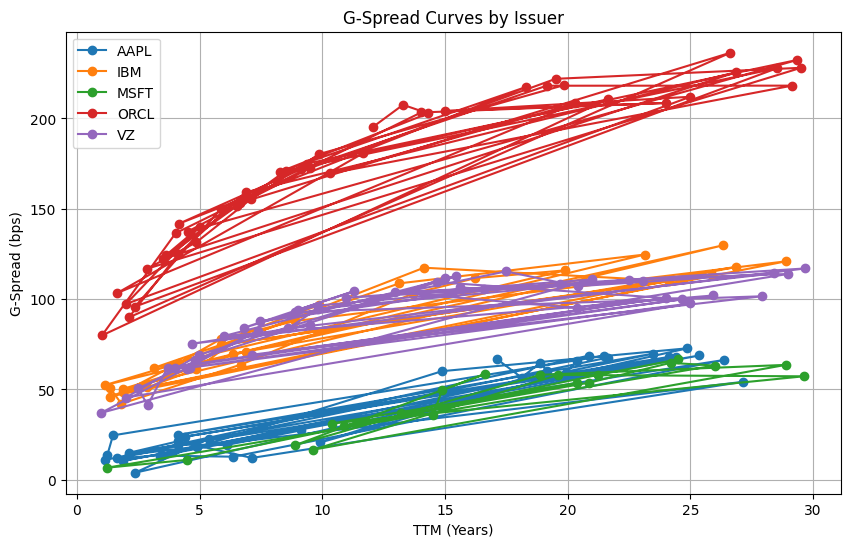

In [54]:
plt.figure(figsize=(10, 6))

for ticker in ["AAPL", "IBM", "MSFT", "ORCL", "VZ"]:
    subset = corp_4a[corp_4a["ticker"] == ticker]

    plt.plot(
        subset["TTM"],
        subset["g_spread"],
        marker="o",
        label=ticker
    )

plt.xlabel("TTM (Years)")
plt.ylabel("G-Spread (bps)")
plt.title("G-Spread Curves by Issuer")
plt.legend()
plt.grid(True)

plt.show()